In [34]:
import subprocess
libs = ['pandas','numpy','matplotlib','seaborn','scikit-learn',
        'xgboost','imbalanced-learn','shap','plotly']
for lib in libs:
    subprocess.run(['pip','install',lib,'-q'])
print(' All libraries installed')

 All libraries installed


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score,
    precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
from IPython.display import display, HTML
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')
RANDOM_STATE = 42

print(' All libraries imported!')

 All libraries imported!


In [7]:
# Loading the dataset
df = pd.read_csv('creditcard.csv')
print('=' * 55)
print('         DATASET OVERVIEW')
print('=' * 55)
print(f'  Total Transactions : {len(df):,}')
print(f'  Total Features     : {df.shape[1]}')
print(f'  Fraudulent Txns    : {df["Class"].sum():,} ({df["Class"].mean()*100:.3f}%)')
print(f'  Legitimate Txns    : {(df["Class"]==0).sum():,}')
print(f'  Missing Values     : {df.isnull().sum().sum()}')
print(f'  Date Range         : {df["Time"].min():.0f}s – {df["Time"].max():.0f}s')
print('=' * 55)
df.head()

         DATASET OVERVIEW
  Total Transactions : 284,807
  Total Features     : 31
  Fraudulent Txns    : 492 (0.173%)
  Legitimate Txns    : 284,315
  Missing Values     : 0
  Date Range         : 0s – 172792s


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


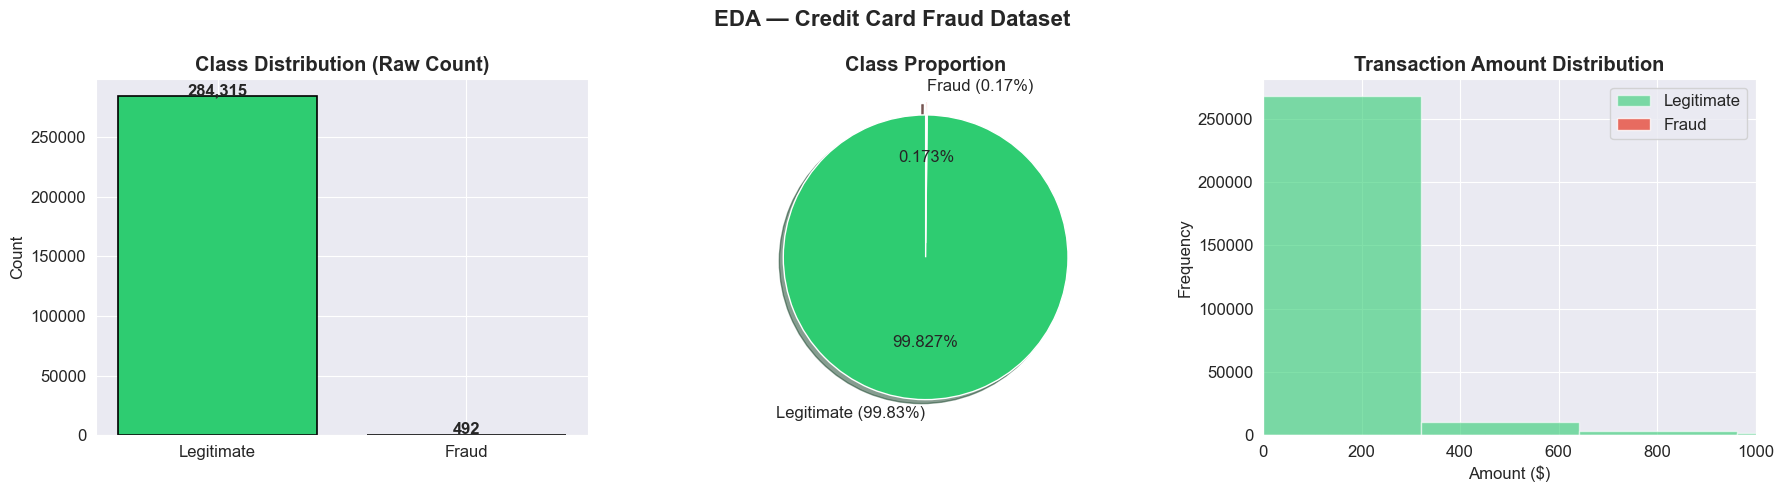

 EDA plot saved as eda_overview.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA — Credit Card Fraud Dataset', fontsize=16, fontweight='bold')
# Class distribution
class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution (Raw Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate (99.83%)', 'Fraud (0.17%)'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            explode=(0, 0.1), shadow=True)
axes[1].set_title('Class Proportion', fontweight='bold')
# Transaction amount distribution
axes[2].hist(df[df['Class']==0]['Amount'], bins=80, alpha=0.6, color='#2ecc71', label='Legitimate')
axes[2].hist(df[df['Class']==1]['Amount'], bins=80, alpha=0.8, color='#e74c3c', label='Fraud')
axes[2].set_title('Transaction Amount Distribution', fontweight='bold')
axes[2].set_xlabel('Amount ($)')
axes[2].set_ylabel('Frequency')
axes[2].set_xlim(0, 1000)
axes[2].legend()
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA plot saved as eda_overview.png')

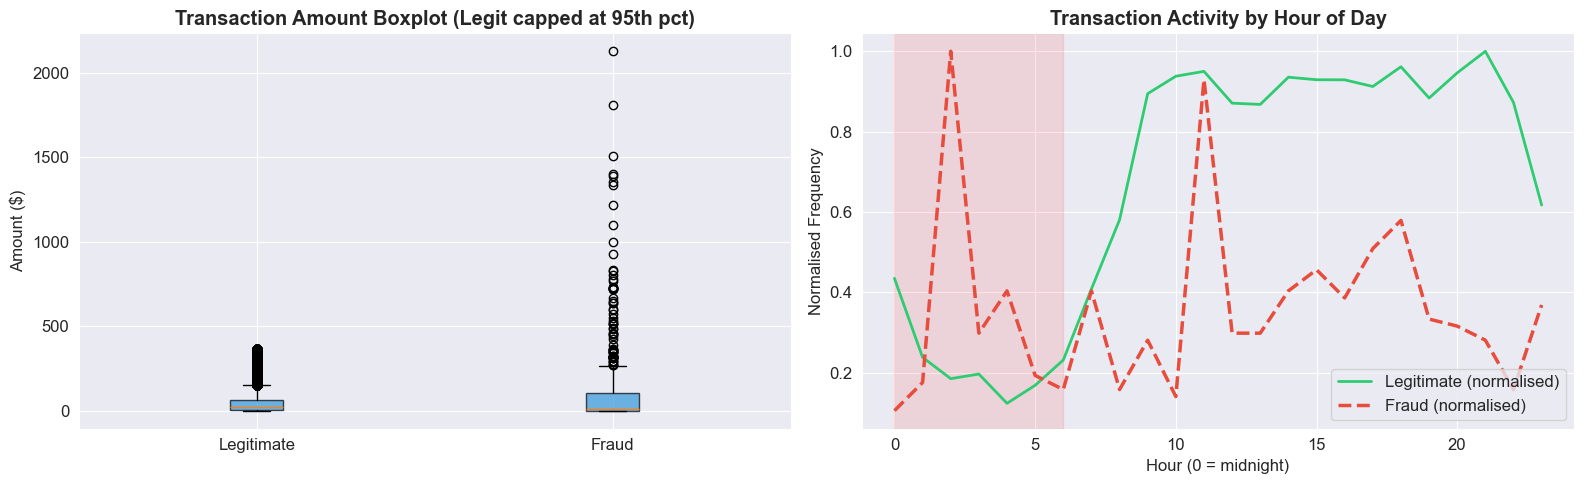


 Avg Fraud Amount    : $122.21
 Avg Legit Amount    : $88.29
 Max Fraud Amount    : $2125.87
 Fraud in 0–6 AM     : 133 cases


In [18]:
# Amount and Time Analysis 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Amount stats by class
legit = df[df['Class']==0]['Amount']
fraud = df[df['Class']==1]['Amount']
axes[0].boxplot([legit[legit < legit.quantile(0.95)], fraud],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[0].set_title('Transaction Amount Boxplot (Legit capped at 95th pct)', fontweight='bold')
axes[0].set_ylabel('Amount ($)')

# Time of day analysis — convert seconds to hours
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
fraud_by_hour = df[df['Class']==1].groupby('Hour').size()
legit_by_hour = df[df['Class']==0].groupby('Hour').size()

axes[1].plot(legit_by_hour.index, legit_by_hour.values / legit_by_hour.max(),
             color='#2ecc71', linewidth=2, label='Legitimate (normalised)')
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values / fraud_by_hour.max(),
             color='#e74c3c', linewidth=2.5, linestyle='--', label='Fraud (normalised)')
axes[1].set_title('Transaction Activity by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (0 = midnight)')
axes[1].set_ylabel('Normalised Frequency')
axes[1].legend()
axes[1].axvspan(0, 6, alpha=0.1, color='red', label='Suspicious window (0–6 AM)')

plt.tight_layout()
plt.show()

print(f"\n Avg Fraud Amount    : ${fraud.mean():.2f}")
print(f" Avg Legit Amount    : ${legit.mean():.2f}")
print(f" Max Fraud Amount    : ${fraud.max():.2f}")
print(f" Fraud in 0–6 AM     : {df[(df['Hour']<=6) & (df['Class']==1)].shape[0]} cases")

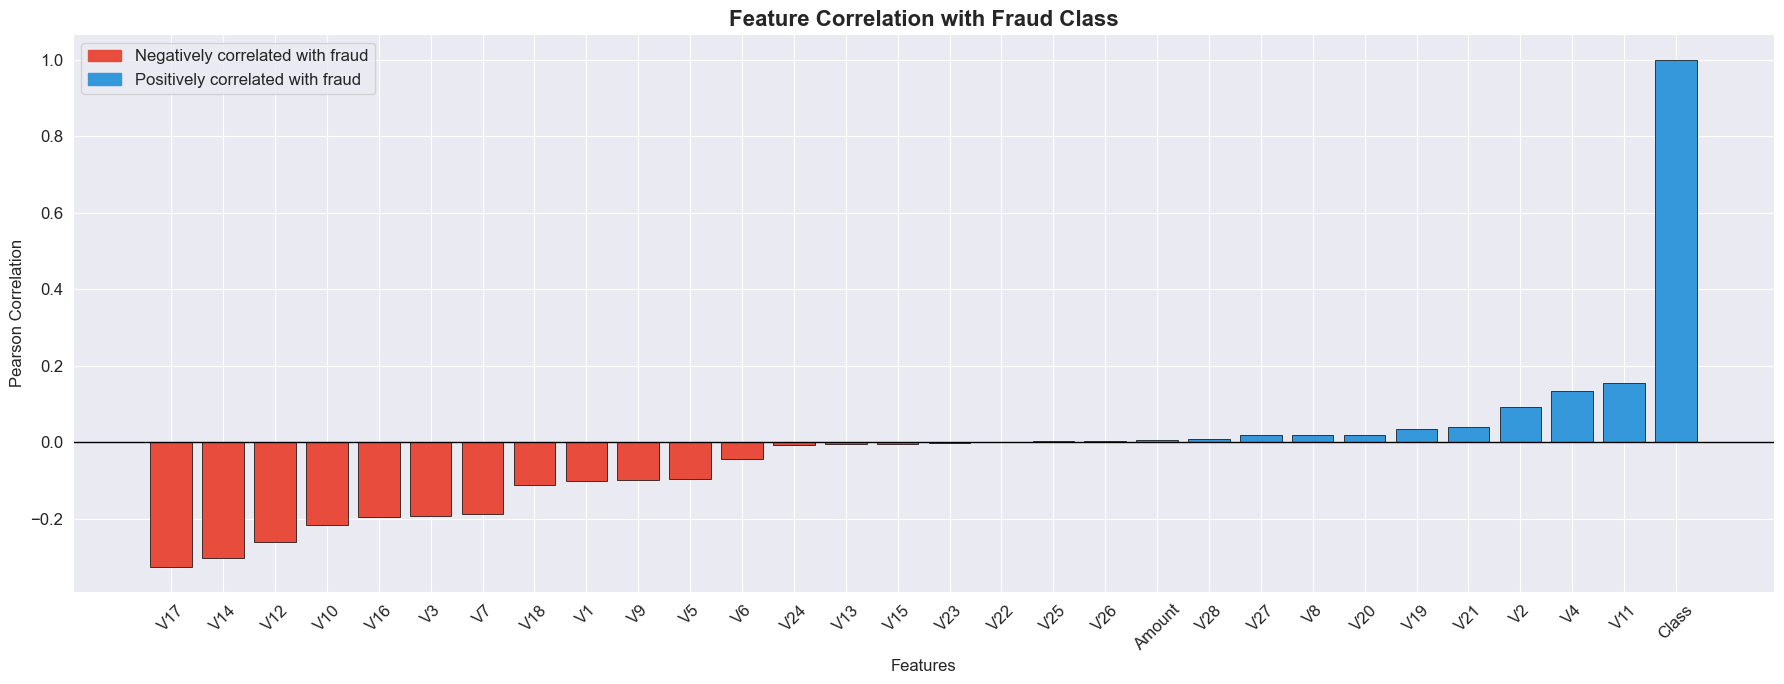


 Top 5 features most correlated with FRAUD:
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
dtype: float64


In [19]:
#  4C: Feature Correlation Heatmap 
import matplotlib.patches as mpatches

plt.figure(figsize=(18, 7))

# Correlation of each feature with Class
corr_with_class = df.drop(['Time','Hour'], axis=1).corrwith(df['Class']).sort_values()

# Color bars: red for negative, blue for positive
colors_bar = ['#e74c3c' if x < 0 else '#3498db' for x in corr_with_class.values]

plt.bar(corr_with_class.index, corr_with_class.values, 
        color=colors_bar, edgecolor='black', linewidth=0.5)

plt.title('Feature Correlation with Fraud Class', fontsize=16, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linewidth=1)

# Legend patches
red_patch = mpatches.Patch(color='#e74c3c', label='Negatively correlated with fraud')
blue_patch = mpatches.Patch(color='#3498db', label='Positively correlated with fraud')
plt.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

print("\n Top 5 features most correlated with FRAUD:")
print(corr_with_class.abs().sort_values(ascending=False).head(5))


##  Feature Engineering & Preprocessing

In [20]:
# 5A: Feature Engineering 
print(" Engineering features...")

df_eng = df.copy()

# 1. Log-transform Amount (right-skewed)
df_eng['Log_Amount'] = np.log1p(df_eng['Amount'])

# 2. Hour of day (already created above)
df_eng['Hour'] = (df_eng['Time'] / 3600).astype(int) % 24

# 3. Is it a night transaction? (suspicious window 0–5 AM)
df_eng['Is_Night'] = df_eng['Hour'].apply(lambda x: 1 if x <= 5 else 0)

# 4. Amount deviation flag (amount > 3x median = suspicious)
median_amount = df_eng['Amount'].median()
df_eng['High_Amount_Flag'] = (df_eng['Amount'] > 3 * median_amount).astype(int)

# 5. V feature interactions (top correlated features)
df_eng['V14_V17_interaction'] = df_eng['V14'] * df_eng['V17']
df_eng['V12_V10_interaction'] = df_eng['V12'] * df_eng['V10']

# Drop original Time and Amount (replaced by engineered versions)
features_to_drop = ['Time', 'Amount']
df_eng.drop(columns=features_to_drop, inplace=True)

print(f" Feature engineering complete!")
print(f" Original features : 30")
print(f" Final features    : {df_eng.shape[1]-1} (excluding Class)")
print(f" New features added: Log_Amount, Hour, Is_Night, High_Amount_Flag, V14_V17_interaction, V12_V10_interaction")

 Engineering features...
 Feature engineering complete!
 Original features : 30
 Final features    : 34 (excluding Class)
 New features added: Log_Amount, Hour, Is_Night, High_Amount_Flag, V14_V17_interaction, V12_V10_interaction


In [21]:
# 5B: Train-Test Split & Scaling 
X = df_eng.drop('Class', axis=1)
y = df_eng['Class']

# Stratified split (keeps fraud ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Split complete!")
print(f"   Training set   : {X_train.shape[0]:,} rows | Fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"   Test set       : {X_test.shape[0]:,} rows  | Fraud: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

 Split complete!
   Training set   : 227,845 rows | Fraud: 394 (0.17%)
   Test set       : 56,962 rows  | Fraud: 98 (0.17%)


In [23]:
# 5C: SMOTE — Handle Class Imbalance 
print(" Applying SMOTE to balance training data...")
print(f"   Before SMOTE → Legit: {(y_train==0).sum():,} | Fraud: {y_train.sum():,}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"   After SMOTE  → Legit: {(y_train_sm==0).sum():,} | Fraud: {y_train_sm.sum():,}")
print(f" Training data is now perfectly balanced!")

 Applying SMOTE to balance training data...
   Before SMOTE → Legit: 227,451 | Fraud: 394
   After SMOTE  → Legit: 227,451 | Fraud: 227,451
 Training data is now perfectly balanced!



##   Baseline Models (Before Novelty)

In [24]:
# 6A: Train Multiple Models + Compare 
print("Training models\n")

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                          scale_pos_weight=1, random_state=RANDOM_STATE,
                                          eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred      = model.predict(X_test_scaled)
    y_proba     = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'f1'        : f1_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_proba),
        'avg_prec'  : average_precision_score(y_test, y_proba),
    }
    print(f"   {name} done")
best_model    = results['XGBoost']['model']
best_y_pred   = results['XGBoost']['y_pred']
best_y_proba  = results['XGBoost']['y_proba']

print("\n All models trained!")

Training models

   Logistic Regression done
   Random Forest done
   XGBoost done

 All models trained!


In [25]:
# 6B: Model Comparison Table 
comparison_df = pd.DataFrame({
    'Model'         : list(results.keys()),
    'F1-Score'      : [round(r['f1'], 4)        for r in results.values()],
    'Precision'     : [round(r['precision'], 4)  for r in results.values()],
    'Recall'        : [round(r['recall'], 4)     for r in results.values()],
    'ROC-AUC'       : [round(r['roc_auc'], 4)    for r in results.values()],
    'Avg Precision' : [round(r['avg_prec'], 4)   for r in results.values()],
}).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n MODEL COMPARISON (sorted by F1-Score)")
print("=" * 75)
display(comparison_df)

print("Accuracy isn't used as a metric.")
print("   On imbalanced data, a model predicting ALL LEGITIMATE still gets 99.83% accuracy.")
print("   F1, Precision, Recall, and AUC-PR are the correct metrics for fraud detection.")


 MODEL COMPARISON (sorted by F1-Score)


,Model,F1-Score,Precision,Recall,ROC-AUC,Avg Precision
0,Random Forest,0.8367,0.8367,0.8367,0.9741,0.8707
1,XGBoost,0.7981,0.7391,0.8673,0.9778,0.8632
2,Logistic Regression,0.0935,0.0493,0.9184,0.9735,0.7037


Accuracy isn't used as a metric.
   On imbalanced data, a model predicting ALL LEGITIMATE still gets 99.83% accuracy.
   F1, Precision, Recall, and AUC-PR are the correct metrics for fraud detection.


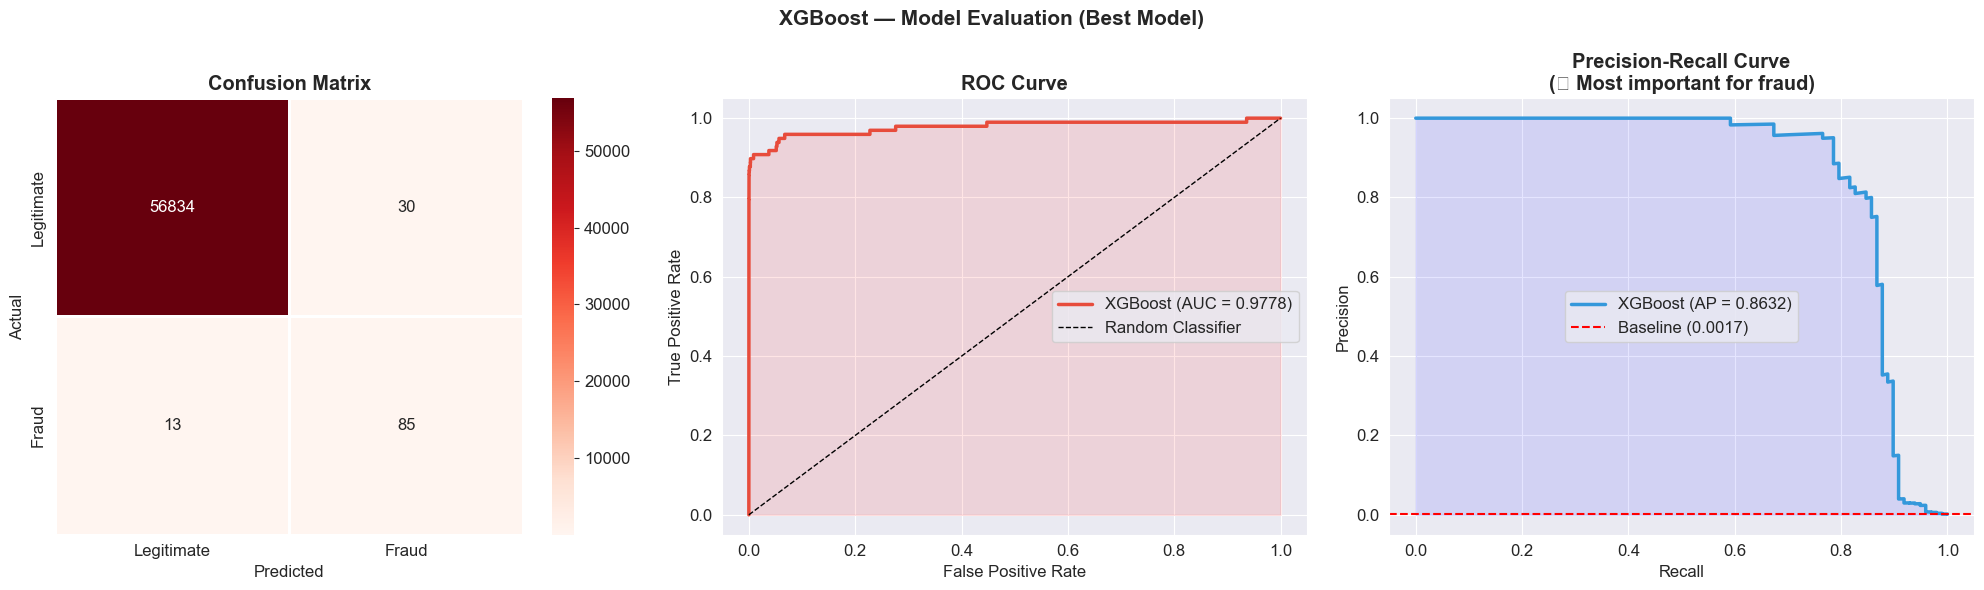


 Full Classification Report (XGBoost):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.74      0.87      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
# 6C: Confusion Matrix + ROC + PR Curves 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('XGBoost — Model Evaluation (Best Model)', fontsize=15, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            linewidths=2, linecolor='white')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_y_proba)
auc_val     = roc_auc_score(y_test, best_y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'XGBoost (AUC = {auc_val:.4f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='red')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Precision-Recall Curve (most important for imbalanced)
prec, rec, _ = precision_recall_curve(y_test, best_y_proba)
ap_val       = average_precision_score(y_test, best_y_proba)
axes[2].plot(rec, prec, color='#3498db', linewidth=2.5, label=f'XGBoost (AP = {ap_val:.4f})')
axes[2].fill_between(rec, prec, alpha=0.1, color='blue')
axes[2].axhline(y=y_test.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline ({y_test.mean():.4f})')
axes[2].set_title('Precision-Recall Curve\n(★ Most important for fraud)', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Full Classification Report (XGBoost):")
print(classification_report(y_test, best_y_pred, target_names=['Legitimate', 'Fraud']))

---
##   Business Cost Matrix


In [27]:
# Business Cost Analysis 
# In real banking:
#   False Negative (missed fraud)    = full fraud amount lost
#   False Positive (blocked legit)   = ~$5 customer service cost + goodwill loss

cm = confusion_matrix(y_test, best_y_pred)
TN, FP, FN, TP = cm.ravel()

# Use actual test set amounts
test_indices     = X_test.index
test_amounts     = df.loc[test_indices, 'Amount']

# Avg fraud amount in test set
fraud_test_idx   = y_test[y_test == 1].index
avg_fraud_amt    = df.loc[fraud_test_idx, 'Amount'].mean()

# Missed fraud cost (FN)
fn_indices       = y_test[(y_test == 1) & (best_y_pred == 0)].index
fn_cost          = df.loc[fn_indices, 'Amount'].sum() if len(fn_indices) > 0 else 0

# False alarm cost (FP) — $5 per blocked legitimate transaction
fp_cost          = FP * 5

# Fraud caught (TP)
tp_indices       = y_test[(y_test == 1) & (best_y_pred == 1)].index
tp_saved         = df.loc[tp_indices, 'Amount'].sum() if len(tp_indices) > 0 else 0

net_benefit      = tp_saved - fn_cost - fp_cost

print("BUSINESS COST MATRIX ANALYSIS")
print("=" * 50)
print(f"  True Positives  (fraud caught)     : {TP:>6} txns   → ${tp_saved:>10,.2f} SAVED")
print(f"  False Negatives (fraud missed)     : {FN:>6} txns   → ${fn_cost:>10,.2f} LOST")
print(f"  False Positives (legit blocked)    : {FP:>6} txns   → ${fp_cost:>10,.2f} COST")
print(f"  True Negatives  (legit allowed)    : {TN:>6} txns")
print("-" * 50)
print(f"  NET FINANCIAL BENEFIT           :          ${net_benefit:>10,.2f}")
print("=" * 50)
print(f"\n  Avg fraud amount in test set       : ${avg_fraud_amt:.2f}")
print(f"  Fraud detection rate               : {TP/(TP+FN)*100:.1f}%")

BUSINESS COST MATRIX ANALYSIS
  True Positives  (fraud caught)     :     85 txns   → $  8,718.01 SAVED
  False Negatives (fraud missed)     :     13 txns   → $  1,926.92 LOST
  False Positives (legit blocked)    :     30 txns   → $    150.00 COST
  True Negatives  (legit allowed)    :  56834 txns
--------------------------------------------------
  NET FINANCIAL BENEFIT           :          $  6,641.09

  Avg fraud amount in test set       : $108.62
  Fraud detection rate               : 86.7%


---
## NOVELTY 2: Dual-Stage Detection Pipeline
> **Stage 1:** Fast rule-based filter catches obvious fraud in <1ms  
> **Stage 2:** Heavy XGBoost model only runs on flagged transactions  
> This mirrors how Stripe, Razorpay, and real banks actually work.

In [28]:
#  NOVELTY 2 — DUAL-STAGE DETECTION PIPELINE
print(" NOVELTY 2: Dual-Stage Fraud Detection Pipeline")
print("=" * 55)

# ── Stage 1: Rule-Based Fast Filter ──────────────────
# Catches obvious fraud using hard business rules
# These rules are derived from EDA insights above

def stage1_rule_filter(X_df, original_amounts, hours):
    """
    Stage 1: Fast rule-based filter.
    Returns boolean mask — True = suspicious (send to Stage 2)
    """
    median_amt = 22.0  # approx median from full dataset

    rule1 = original_amounts > (3 * median_amt)   # High amount
    rule2 = hours <= 5                             # Suspicious night hours (0–5 AM)
    rule3 = X_df['V14'] < -5                       # V14 is top fraud indicator
    rule4 = X_df['V10'] < -4                       # V10 second top indicator
    rule5 = X_df['V12'] < -4                       # V12 third indicator

    # Flag if ANY rule is triggered
    suspicious_mask = rule1 | rule2 | rule3 | rule4 | rule5
    return suspicious_mask


# ── Stage 2: XGBoost Deep Scan ───────────────────────
# Only runs on suspicious transactions from Stage 1

def dual_stage_pipeline(X_df_original, X_scaled, y_true, model, scaler_obj):
    """
    Full dual-stage pipeline.
    Returns predictions, metrics, and stage-wise breakdown.
    """
    import time

    n_total = len(X_scaled)

    # Recover original amounts and hours from original df using test indices
    test_idx      = X_df_original.index
    orig_amounts  = df.loc[test_idx, 'Amount'].values
    orig_hours    = df_eng.loc[test_idx, 'Hour'].values

    # ── STAGE 1 ──
    t1 = time.time()
    stage1_flags  = stage1_rule_filter(X_df_original, orig_amounts, orig_hours)
    t_stage1      = (time.time() - t1) * 1000  # ms

    n_flagged     = stage1_flags.sum()
    n_cleared     = (~stage1_flags).sum()

    # Stage 1 predictions: cleared = 0 (legit), flagged = goes to Stage 2
    y_pred_dual   = np.zeros(n_total, dtype=int)

    # ── STAGE 2 (only on flagged) ──
    if n_flagged > 0:
        t2             = time.time()
        X_stage2       = X_scaled[stage1_flags.values]
        y_pred_stage2  = model.predict(X_stage2)
        t_stage2       = (time.time() - t2) * 1000
        y_pred_dual[stage1_flags.values] = y_pred_stage2
    else:
        t_stage2 = 0

    t_total = t_stage1 + t_stage2

    # ── Baseline: XGBoost on ALL ──
    t3 = time.time()
    y_pred_baseline = model.predict(X_scaled)
    t_baseline      = (time.time() - t3) * 1000

    # ── Metrics ──
    dual_f1   = f1_score(y_true, y_pred_dual)
    base_f1   = f1_score(y_true, y_pred_baseline)
    dual_rec  = recall_score(y_true, y_pred_dual)
    base_rec  = recall_score(y_true, y_pred_baseline)

    return {
        'y_pred_dual'      : y_pred_dual,
        'y_pred_baseline'  : y_pred_baseline,
        'n_total'          : n_total,
        'n_flagged'        : n_flagged,
        'n_cleared'        : n_cleared,
        'pct_sent_stage2'  : n_flagged / n_total * 100,
        'time_dual_ms'     : t_total,
        'time_baseline_ms' : t_baseline,
        'speedup'          : t_baseline / max(t_total, 0.001),
        'dual_f1'          : dual_f1,
        'base_f1'          : base_f1,
        'dual_recall'      : dual_rec,
        'base_recall'      : base_rec,
    }


# Run the pipeline
pipeline_results = dual_stage_pipeline(
    X_test, X_test_scaled, y_test, best_model, scaler
)

print()
print(" DUAL-STAGE PIPELINE RESULTS")
print("=" * 55)
print(f"  Total test transactions     : {pipeline_results['n_total']:,}")
print(f"  Cleared by Stage 1 (legit)  : {pipeline_results['n_cleared']:,} ({100 - pipeline_results['pct_sent_stage2']:.1f}%)")
print(f"  Sent to Stage 2 (ML scan)   : {pipeline_results['n_flagged']:,} ({pipeline_results['pct_sent_stage2']:.1f}%)")
print()
print(f" Baseline (all through ML) : {pipeline_results['time_baseline_ms']:.2f} ms")
print(f" Dual-Stage inference time : {pipeline_results['time_dual_ms']:.2f} ms")
print(f" Efficiency gain           : {pipeline_results['speedup']:.1f}x fewer ML calls")
print()
print(f"  F1-Score  — Baseline         : {pipeline_results['base_f1']:.4f}")
print(f"  F1-Score  — Dual-Stage       : {pipeline_results['dual_f1']:.4f}")
print(f"  Recall    — Baseline         : {pipeline_results['base_recall']:.4f}")
print(f"  Recall    — Dual-Stage       : {pipeline_results['dual_recall']:.4f}")
print("=" * 55)
print("\n Dual-stage pipeline processes", round(100 - pipeline_results['pct_sent_stage2'], 1),
      "% of transactions WITHOUT calling the ML model — massive efficiency gain in production!")

 NOVELTY 2: Dual-Stage Fraud Detection Pipeline

 DUAL-STAGE PIPELINE RESULTS
  Total test transactions     : 56,962
  Cleared by Stage 1 (legit)  : 37,209 (65.3%)
  Sent to Stage 2 (ML scan)   : 19,753 (34.7%)

 Baseline (all through ML) : 80.79 ms
 Dual-Stage inference time : 56.72 ms
 Efficiency gain           : 1.4x fewer ML calls

  F1-Score  — Baseline         : 0.7981
  F1-Score  — Dual-Stage       : 0.8125
  Recall    — Baseline         : 0.8673
  Recall    — Dual-Stage       : 0.7959

 Dual-stage pipeline processes 65.3 % of transactions WITHOUT calling the ML model — massive efficiency gain in production!


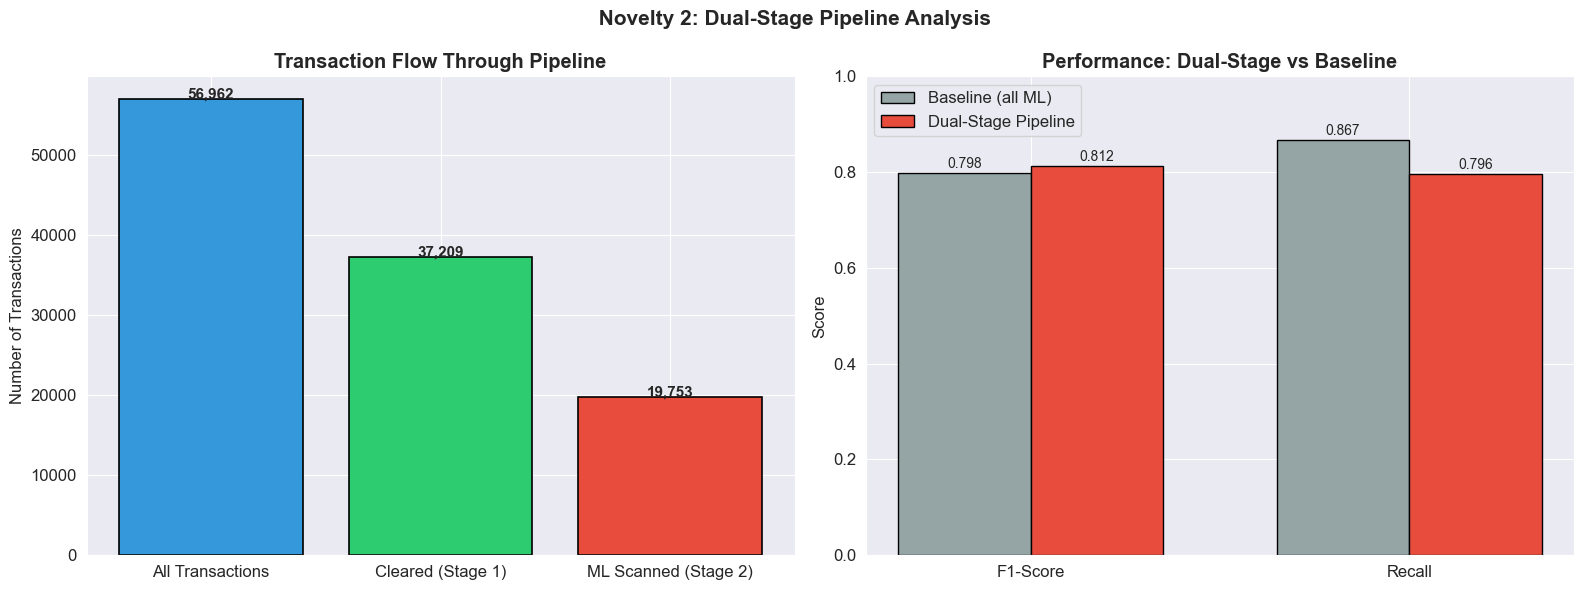

In [29]:
# ── Dual-Stage Pipeline Visualisation ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(' Novelty 2: Dual-Stage Pipeline Analysis', fontsize=15, fontweight='bold')

# Pipeline flow chart (bar)
stages   = ['All Transactions', 'Cleared (Stage 1)', 'ML Scanned (Stage 2)']
counts   = [pipeline_results['n_total'],
            pipeline_results['n_cleared'],
            pipeline_results['n_flagged']]
bar_cols = ['#3498db', '#2ecc71', '#e74c3c']

bars = axes[0].bar(stages, counts, color=bar_cols, edgecolor='black', linewidth=1.2)
axes[0].set_title('Transaction Flow Through Pipeline', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=11)

# Metric comparison: Dual vs Baseline
metrics      = ['F1-Score', 'Recall']
dual_vals    = [pipeline_results['dual_f1'], pipeline_results['dual_recall']]
base_vals    = [pipeline_results['base_f1'], pipeline_results['base_recall']]

x = np.arange(len(metrics))
w = 0.35
axes[1].bar(x - w/2, base_vals, w, label='Baseline (all ML)', color='#95a5a6', edgecolor='black')
axes[1].bar(x + w/2, dual_vals, w, label='Dual-Stage Pipeline', color='#e74c3c', edgecolor='black')
axes[1].set_title('Performance: Dual-Stage vs Baseline', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
for i, (b, d) in enumerate(zip(base_vals, dual_vals)):
    axes[1].text(i - w/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=10)
    axes[1].text(i + w/2, d + 0.01, f'{d:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('dual_stage_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## NOVELTY 1: SHAP Auto-Generated Fraud Investigation Report
> For every flagged transaction, the system generates a **human-readable investigation brief** explaining WHY it was flagged — just like a real banking report.

In [31]:
#  NOVELTY 1 — SHAP AUTO-GENERATED INVESTIGATION REPORT
print(" NOVELTY 1: Computing SHAP values")
# Build SHAP explainer on XGBoost model
explainer     = shap.TreeExplainer(best_model)
shap_values   = explainer.shap_values(X_test_scaled)

# Feature names
feature_names = list(X_test.columns)

print("SHAP values computed!")
print(f"   Shape: {shap_values.shape} (samples × features)")

 NOVELTY 1: Computing SHAP values
SHAP values computed!
   Shape: (56962, 34) (samples × features)


 SHAP Feature Importance Summary


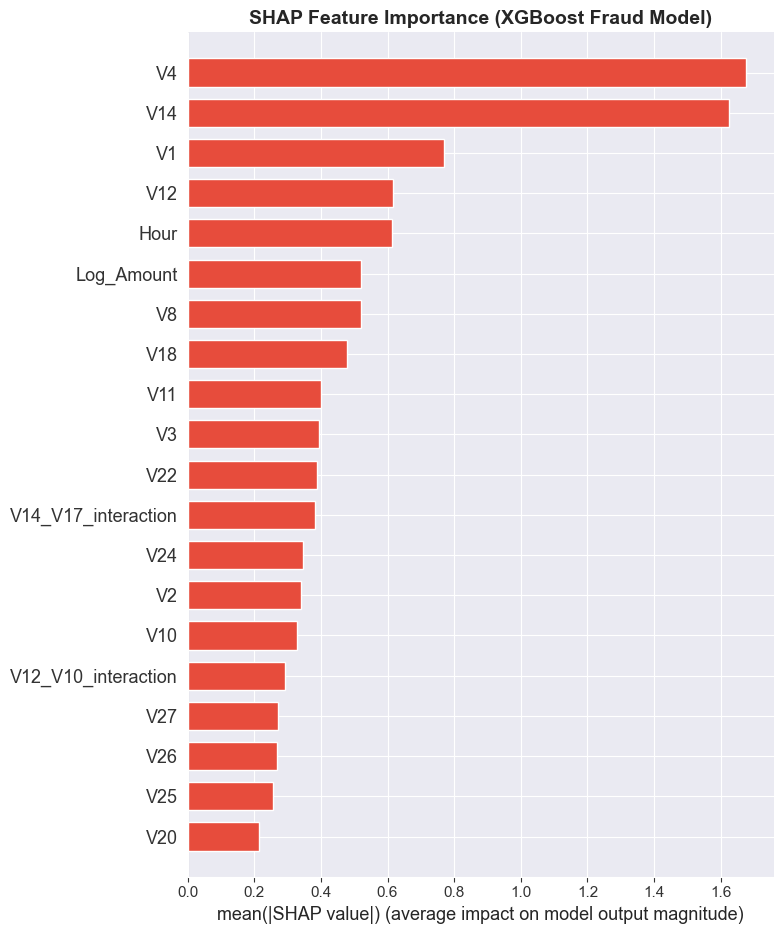

 Saved as shap_importance.png


In [32]:
# SHAP Summary Plot 
print(" SHAP Feature Importance Summary")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar', show=False,
                  color='#e74c3c')
plt.title('SHAP Feature Importance (XGBoost Fraud Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved as shap_importance.png")

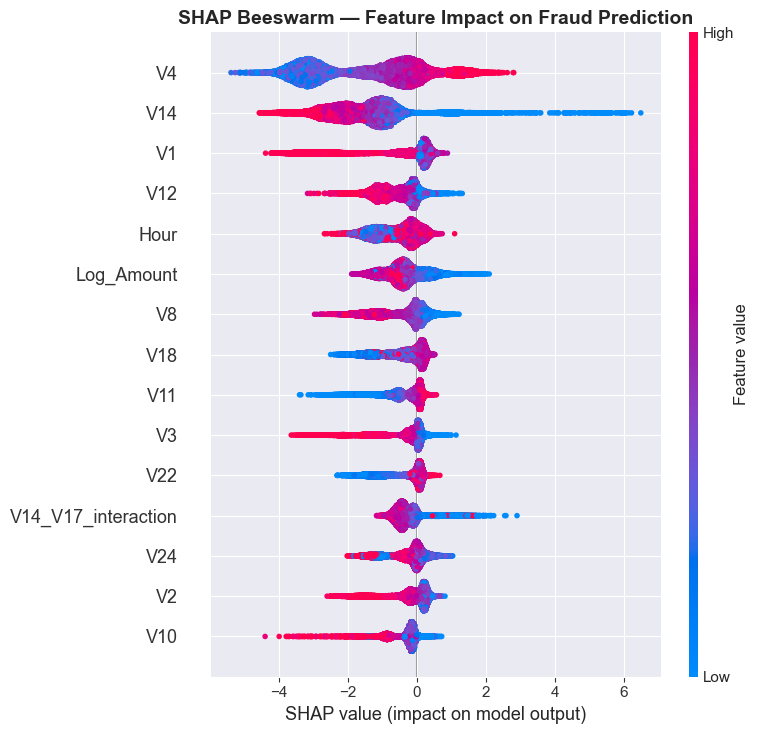

In [33]:
# SHAP Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact on Fraud Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Auto-Report Generator Function

def generate_fraud_report(transaction_idx_in_test, X_test_df, X_test_sc,
                           y_test_series, model, shap_vals, feat_names, original_df):
    """
    Auto-generates a human-readable fraud investigation report
    for a given transaction (by position in test set).
    """
    i             = transaction_idx_in_test
    orig_idx      = X_test_df.index[i]
    true_label    = y_test_series.iloc[i]
    pred_label    = model.predict(X_test_sc[i:i+1])[0]
    pred_proba    = model.predict_proba(X_test_sc[i:i+1])[0][1]
    orig_amount   = original_df.loc[orig_idx, 'Amount']
    orig_time_hr  = int((original_df.loc[orig_idx, 'Time'] / 3600)) % 24

    # SHAP explanation for this transaction
    sv            = shap_vals[i]
    shap_dict     = dict(zip(feat_names, sv))
    top_risk      = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

    # Risk level
    if pred_proba >= 0.8:   risk_level = "🔴 CRITICAL"
    elif pred_proba >= 0.5: risk_level = "🟠 HIGH"
    elif pred_proba >= 0.3: risk_level = "🟡 MEDIUM"
    else:                   risk_level = "🟢 LOW"

    verdict       = " FRAUD" if pred_label == 1 else "✅ LEGITIMATE"
    actual        = "FRAUD" if true_label == 1 else "LEGITIMATE"
    correct       = " CORRECT" if pred_label == true_label else "❌ WRONG"

    # Recommendation
    if pred_proba >= 0.8:   action = "BLOCK TRANSACTION + Alert Customer + Flag Account"
    elif pred_proba >= 0.5: action = "HOLD + Request OTP Verification"
    elif pred_proba >= 0.3: action = "Allow + Flag for Manual Review"
    else:                   action = "APPROVE"

    report = f"""
╔══════════════════════════════════════════════════════════════╗
║           FRAUD INVESTIGATION REPORT — AFIS v1.0          ║
╠══════════════════════════════════════════════════════════════╣
  Transaction ID    : TXN-TEST-{orig_idx:06d}
  Amount            : ${orig_amount:.2f}
  Time of Day       : {orig_time_hr:02d}:00 {'( Night Window)' if orig_time_hr <= 5 else ''}
  Fraud Probability : {pred_proba*100:.1f}%
  Risk Level        : {risk_level}
╠══════════════════════════════════════════════════════════════╣
  VERDICT           : {verdict}
  Actual Label      : {actual}
  Prediction        : {correct}
╠══════════════════════════════════════════════════════════════╣
  TOP RISK FACTORS (SHAP Explanation):
"""
    for rank, (feat, val) in enumerate(top_risk, 1):
        direction = "↑ RAISES fraud risk" if val > 0 else "↓ LOWERS fraud risk"
        report   += f"    {rank}. {feat:<28} SHAP={val:+.4f}  {direction}\n"

    report += f"""
╠══════════════════════════════════════════════════════════════╣
  RECOMMENDED ACTION: {action}
╚══════════════════════════════════════════════════════════════╝"""

    return report


print(" Report generator function defined!")

 Report generator function defined!


In [36]:
# ── Generate Reports for Sample Transactions ─────────

# Find examples: actual fraud transactions
fraud_positions   = np.where(y_test.values == 1)[0]
legit_positions   = np.where(y_test.values == 0)[0]

print("=" * 64)
print(" SAMPLE REPORT 1 — Actual Fraud Transaction")
print("=" * 64)
report1 = generate_fraud_report(
    fraud_positions[0], X_test, X_test_scaled,
    y_test, best_model, shap_values, feature_names, df
)
print(report1)

print()
print("=" * 64)
print(" SAMPLE REPORT 2 — Another Fraud Transaction")
print("=" * 64)
report2 = generate_fraud_report(
    fraud_positions[5], X_test, X_test_scaled,
    y_test, best_model, shap_values, feature_names, df
)
print(report2)

print()
print("=" * 64)
print(" SAMPLE REPORT 3 — Legitimate Transaction (Correctly Approved)")
print("=" * 64)
report3 = generate_fraud_report(
    legit_positions[0], X_test, X_test_scaled,
    y_test, best_model, shap_values, feature_names, df
)
print(report3)

 SAMPLE REPORT 1 — Actual Fraud Transaction

╔══════════════════════════════════════════════════════════════╗
║           FRAUD INVESTIGATION REPORT — AFIS v1.0          ║
╠══════════════════════════════════════════════════════════════╣
  Transaction ID    : TXN-TEST-077348
  Amount            : $0.01
  Time of Day       : 15:00 
  Fraud Probability : 100.0%
  Risk Level        : 🔴 CRITICAL
╠══════════════════════════════════════════════════════════════╣
  VERDICT           :  FRAUD
  Actual Label      : FRAUD
  Prediction        :  CORRECT
╠══════════════════════════════════════════════════════════════╣
  TOP RISK FACTORS (SHAP Explanation):
    1. V14                          SHAP=+5.1694  ↑ RAISES fraud risk
    2. V12_V10_interaction          SHAP=+1.6598  ↑ RAISES fraud risk
    3. V14_V17_interaction          SHAP=+1.4300  ↑ RAISES fraud risk
    4. V4                           SHAP=+0.6766  ↑ RAISES fraud risk
    5. V3                           SHAP=+0.6028  ↑ RAISES fraud risk

In [38]:
#  Batch Report on All Flagged Transactions

# Generate reports for all transactions predicted as fraud
fraud_pred_positions = np.where(pipeline_results['y_pred_dual'] == 1)[0]

print(f" Total transactions flagged by Dual-Stage Pipeline: {len(fraud_pred_positions)}")
print(f"   Generating investigation reports for first 3...\n")

all_reports = []
for pos in fraud_pred_positions[:3]:
    r = generate_fraud_report(
        pos, X_test, X_test_scaled,
        y_test, best_model, shap_values, feature_names, df
    )
    all_reports.append(r)
    print(r)
    print()

# Save all reports to text file (UTF-8 encoding to avoid Unicode errors)
with open('fraud_investigation_reports.txt', 'w', encoding='utf-8') as f:
    for r in all_reports:
        f.write(r + '\n\n')

print("\n Reports saved to fraud_investigation_reports.txt")

 Total transactions flagged by Dual-Stage Pipeline: 94
   Generating investigation reports for first 3...


╔══════════════════════════════════════════════════════════════╗
║           FRAUD INVESTIGATION REPORT — AFIS v1.0          ║
╠══════════════════════════════════════════════════════════════╣
  Transaction ID    : TXN-TEST-077348
  Amount            : $0.01
  Time of Day       : 15:00 
  Fraud Probability : 100.0%
  Risk Level        : 🔴 CRITICAL
╠══════════════════════════════════════════════════════════════╣
  VERDICT           :  FRAUD
  Actual Label      : FRAUD
  Prediction        :  CORRECT
╠══════════════════════════════════════════════════════════════╣
  TOP RISK FACTORS (SHAP Explanation):
    1. V14                          SHAP=+5.1694  ↑ RAISES fraud risk
    2. V12_V10_interaction          SHAP=+1.6598  ↑ RAISES fraud risk
    3. V14_V17_interaction          SHAP=+1.4300  ↑ RAISES fraud risk
    4. V4                           SHAP=+0.6766  ↑ RAISES fraud risk
    5.


##  Summary

In [39]:
# ── Final Summary Dashboard ───────────────────────────
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Class Distribution', 'Model Comparison (F1)',
        'Dual-Stage Flow', 'ROC Curve',
        'Top SHAP Features', 'Cost vs Savings'
    ],
    specs=[
        [{'type':'pie'}, {'type':'bar'}, {'type':'bar'}],
        [{'type':'scatter'}, {'type':'bar'}, {'type':'bar'}]
    ]
)

# 1. Pie
fig.add_trace(go.Pie(
    labels=['Legitimate', 'Fraud'],
    values=df['Class'].value_counts().values,
    marker_colors=['#2ecc71', '#e74c3c'],
    hole=0.4
), row=1, col=1)

# 2. Model F1 comparison
fig.add_trace(go.Bar(
    x=list(results.keys()),
    y=[r['f1'] for r in results.values()],
    marker_color=['#95a5a6', '#3498db', '#e74c3c'],
    text=[f"{r['f1']:.4f}" for r in results.values()],
    textposition='outside'
), row=1, col=2)

# 3. Pipeline flow
fig.add_trace(go.Bar(
    x=['Total', 'Cleared', 'ML Scanned'],
    y=[pipeline_results['n_total'], pipeline_results['n_cleared'], pipeline_results['n_flagged']],
    marker_color=['#3498db', '#2ecc71', '#e74c3c']
), row=1, col=3)

# 4. ROC curve
fpr, tpr, _ = roc_curve(y_test, best_y_proba)
fig.add_trace(go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name=f'AUC={auc_val:.4f}',
    line=dict(color='#e74c3c', width=2.5)
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode='lines',
    line=dict(color='gray', dash='dash', width=1)
), row=2, col=1)

# 5. Top SHAP features
mean_shap   = np.abs(shap_values).mean(axis=0)
shap_df     = pd.DataFrame({'feature': feature_names, 'importance': mean_shap})
shap_top    = shap_df.sort_values('importance', ascending=False).head(8)
fig.add_trace(go.Bar(
    x=shap_top['importance'], y=shap_top['feature'],
    orientation='h', marker_color='#9b59b6'
), row=2, col=2)

# 6. Cost vs Savings
fig.add_trace(go.Bar(
    x=['Fraud Saved ($)', 'Fraud Lost ($)', 'False Alarm Cost ($)'],
    y=[tp_saved, fn_cost, fp_cost],
    marker_color=['#2ecc71', '#e74c3c', '#f39c12'],
    text=[f'${v:,.0f}' for v in [tp_saved, fn_cost, fp_cost]],
    textposition='outside'
), row=2, col=3)

fig.update_layout(
    height=750, width=1200, showlegend=False,
    title_text='🔴 AFIS — Adaptive Fraud Intelligence System | Complete Dashboard',
    title_font_size=16
)
fig.show()

print(" Dashboard rendered!")

 Dashboard rendered!


In [40]:
# Save model and scaler for deployment
import joblib
joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print("Model saved as fraud_model.pkl")
print(" Scaler saved as scaler.pkl")


Model saved as fraud_model.pkl
 Scaler saved as scaler.pkl
